In [1]:
!pip install split-folders

import os
import numpy as np
import pandas as pd
import splitfolders
import tensorflow as tf
import matplotlib.pyplot as plt
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
from tensorflow.keras.optimizers import Adam
from keras.models import Sequential
from keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from keras.callbacks import ModelCheckpoint, EarlyStopping

from torchvision.datasets import ImageFolder
from torch.utils.data import DataLoader

In [2]:
from google.colab import drive
drive.mount('/content/drive')

!unzip -q "/content/drive/My Drive/Projek/Dataset/AugmentedAlzheimerDataset.zip" -d /content/local_dataset

old_path = "/content/local_dataset/AugmentedAlzheimerDataset"
path = "/content/dataset_split"

class_labels = ['NonDemented', 'MildDemented', 'VeryMildDemented', 'ModerateDemented']
num_classes = len(class_labels)

# 80:10:10
splitfolders.ratio(old_path, output=path, seed=42, ratio=(.8, .1, .1))


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
replace /content/local_dataset/AugmentedAlzheimerDataset/MildDemented/00046ff7-0fae-4796-9a2b-2df47095bfe6.jpg? [y]es, [n]o, [A]ll, [N]one, [r]ename: N


Copying files: 33984 files [00:07, 4396.82 files/s]


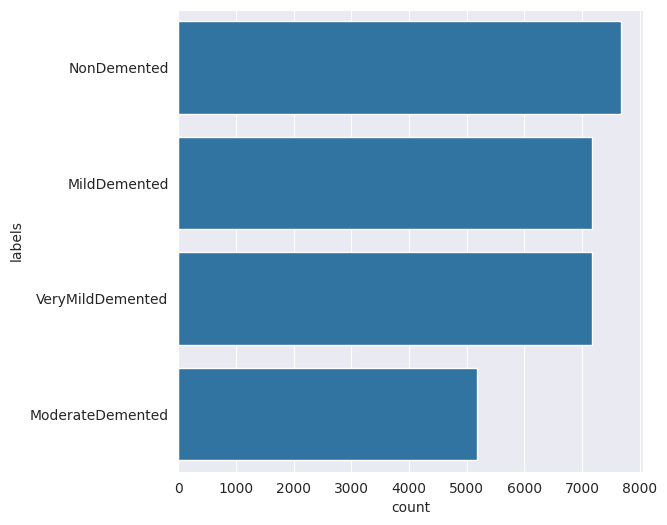

In [3]:
# Buat daftar yang menyimpan data untuk setiap nama file, path file, dan label dalam data
file_name = []
labels = []
full_path = []

train_folder_path = os.path.join(path, "train")

# Dapatkan nama file gambar, path file, dan label satu per satu dengan looping, dan simpan sebagai dataframe
for root, subdirs, files in os.walk(train_folder_path):
    for name in files:
        full_path.append(os.path.join(root, name))
        labels.append(root.split('/')[-1])
        file_name.append(name)

distribution_train = pd.DataFrame({"path":full_path, 'file_name':file_name, "labels":labels})

# Plot distribusi gambar di setiap kelas
Label = distribution_train['labels']
plt.figure(figsize = (6,6))
sns.set_style("darkgrid")
plot_data = sns.countplot(Label, order=class_labels)

In [4]:
img_width, img_height = 200, 190
img_channels = 3
batch_size = 32
epochs = 70

In [5]:
datagen = ImageDataGenerator(rescale=1./255)

train_ds = datagen.flow_from_directory(
    f"{path}/train",
    target_size=(img_height, img_width),
    batch_size=batch_size,
    class_mode='categorical',
    classes=class_labels,
    shuffle=True,
    seed=42
)

val_ds = datagen.flow_from_directory(
    f"{path}/val",
    target_size=(img_height, img_width),
    batch_size=batch_size,
    class_mode='categorical',
    classes=class_labels,
    shuffle=False,
    seed=42
)

test_ds = datagen.flow_from_directory(
    f"{path}/test",
    target_size=(img_height, img_width),
    batch_size=batch_size,
    class_mode='categorical',
    classes=class_labels,
    shuffle=False,
    seed=42
)

print("Class Mapping:")
print(train_ds.class_indices)

Found 27187 images belonging to 4 classes.
Found 3398 images belonging to 4 classes.
Found 3399 images belonging to 4 classes.
Class Mapping:
{'NonDemented': 0, 'MildDemented': 1, 'VeryMildDemented': 2, 'ModerateDemented': 3}


In [8]:
model = Sequential()

model.add(Conv2D(32, (3, 3), activation='relu', input_shape=(img_height, img_width, img_channels)))
model.add(MaxPooling2D((2, 2)))
model.add(Dropout(0.2))

model.add(Conv2D(64, (3, 3), activation='relu'))
model.add(MaxPooling2D((2, 2)))
model.add(Dropout(0.2))

model.add(Conv2D(64, (3, 3), activation='relu'))
model.add(MaxPooling2D((2, 2)))
model.add(Dropout(0.2))

model.add(Conv2D(128, (3, 3), activation='relu'))
model.add(MaxPooling2D((2, 2)))
model.add(Dropout(0.2))

model.add(Flatten())

model.add(Dense(64, activation='relu'))
model.add(Dropout(0.5))

model.add(Dense(4, activation='softmax'))

# Compile Model
model.compile(optimizer=Adam(learning_rate=0.0001), loss='categorical_crossentropy', metrics=['accuracy'])
model.summary()

# Callbacks
checkpoint = ModelCheckpoint('best_model.keras', monitor='val_loss', save_best_only=True, mode='min')
early_stopping = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)

# Train Data
history = model.fit(
    train_ds,
    epochs=epochs,
    validation_data=val_ds,
    callbacks=[checkpoint, early_stopping]
)

# Evaluasi Model
evaluation = model.evaluate(test_ds)

print("HASIL EVALUASI")
print("Loss:", evaluation[0])
print("Accuracy:", evaluation[1])

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_4 (Conv2D)               │ (None, 188, 198, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 94, 99, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 94, 99, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 92, 97, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 46, 48, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ (None, 46, 48, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 44, 46, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_6 (MaxPooling2D)  │ (None, 22, 23, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_7 (Dropout)             │ (None, 22, 23, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 20, 21, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_7 (MaxPooling2D)  │ (None, 10, 10, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_8 (Dropout)             │ (None, 10, 10, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 12800)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 64)             │       819,264 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_9 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 4)              │           260 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 949,700 (3.62 MB)

 Trainable params: 949,700 (3.62 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/70
850/850 ━━━━━━━━━━━━━━━━━━━━ 63s 59ms/step - accuracy: 0.3343 - loss: 1.3172 - val_accuracy: 0.3252 - val_loss: 1.3169
Epoch 2/70
850/850 ━━━━━━━━━━━━━━━━━━━━ 41s 48ms/step - accuracy: 0.4502 - loss: 1.1631 - val_accuracy: 0.4526 - val_loss: 1.1592
Epoch 3/70
850/850 ━━━━━━━━━━━━━━━━━━━━ 40s 47ms/step - accuracy: 0.4984 - loss: 1.0939 - val_accuracy: 0.5727 - val_loss: 1.0350
Epoch 4/70
850/850 ━━━━━━━━━━━━━━━━━━━━ 42s 49ms/step - accuracy: 0.5484 - loss: 1.0346 - val_accuracy: 0.6183 - val_loss: 0.9450
Epoch 5/70
850/850 ━━━━━━━━━━━━━━━━━━━━ 40s 47ms/step - accuracy: 0.5629 - loss: 0.9761 - val_accuracy: 0.6366 - val_loss: 0.8830
Epoch 6/70
850/850 ━━━━━━━━━━━━━━━━━━━━ 40s 46ms/step - accuracy: 0.5779 - loss: 0.9285 - val_accuracy: 0.6401 - val_loss: 0.8506
Epoch 7/70
850/850 ━━━━━━━━━━━━━━━━━━━━ 41s 48ms/step - accuracy: 0.5926 - loss: 0.8973 - val_accuracy: 0.6318 - val_loss: 0.8032
Epoch 8/70
850/850 ━━━━━━━━━━━━━━━━━━━━ 41s 47ms/step - accuracy: 0.6040 - loss: 0.8719 - 

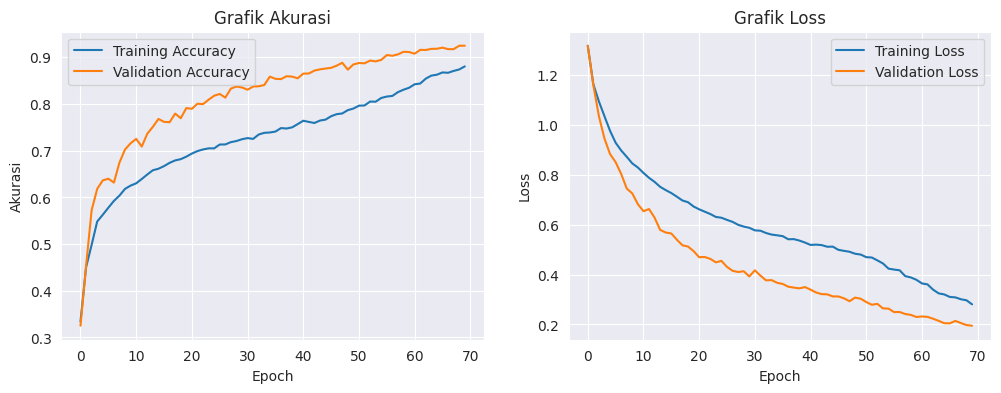

In [9]:
# Grafik Akurasi
plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Grafik Akurasi')
plt.xlabel('Epoch')
plt.ylabel('Akurasi')
plt.legend()

# Grafik Loss
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Grafik Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.show()

107/107 ━━━━━━━━━━━━━━━━━━━━ 8s 73ms/step


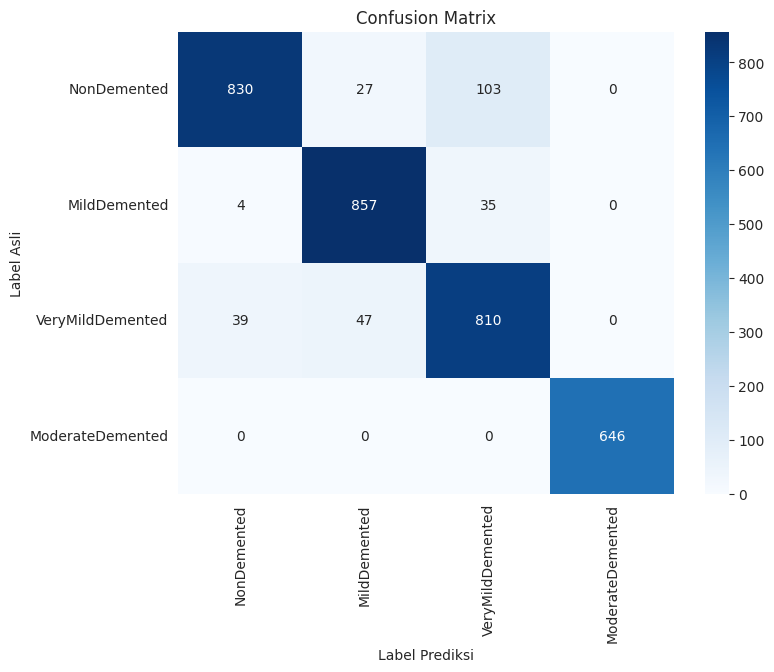

                  precision    recall  f1-score   support

     NonDemented       0.95      0.86      0.91       960
    MildDemented       0.92      0.96      0.94       896
VeryMildDemented       0.85      0.90      0.88       896
ModerateDemented       1.00      1.00      1.00       646

        accuracy                           0.92      3398
       macro avg       0.93      0.93      0.93      3398
    weighted avg       0.93      0.92      0.92      3398



In [12]:
Y_pred = model.predict(val_ds)
y_pred = np.argmax(Y_pred, axis=1)

y_true = val_ds.classes

# Confusion Matrix
cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_labels, yticklabels=class_labels)
plt.title('Confusion Matrix')
plt.ylabel('Label Asli')
plt.xlabel('Label Prediksi')
plt.show()

print(classification_report(y_true, y_pred, target_names=class_labels))

In [32]:
save_path = 'mymodel/'
tf.saved_model.save(model, save_path)

In [33]:
!zip -r /content/saved_model.zip /content/mymodel

  adding: content/mymodel/ (stored 0%)
  adding: content/mymodel/fingerprint.pb (stored 0%)
  adding: content/mymodel/assets/ (stored 0%)
  adding: content/mymodel/variables/ (stored 0%)
  adding: content/mymodel/variables/variables.index (deflated 64%)
  adding: content/mymodel/variables/variables.data-00000-of-00001 (deflated 22%)
  adding: content/mymodel/saved_model.pb (deflated 87%)


In [34]:
from google.colab import files
files.download("/content/saved_model.zip")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>